In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('owid-covid-data.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN


In [15]:
australia = df[df['location'] == 'Australia'].copy()

In [16]:
australia = australia[['date', 'new_cases', 'new_deaths', 'total_cases', 'total_deaths']]
australia.head(10)

,date,new_cases,new_deaths,total_cases,total_deaths
21776,2020-01-05,0.0,0.0,0.0,0.0
21777,2020-01-06,0.0,0.0,0.0,0.0
21778,2020-01-07,0.0,0.0,0.0,0.0
21779,2020-01-08,0.0,0.0,0.0,0.0
21780,2020-01-09,0.0,0.0,0.0,0.0
21781,2020-01-10,0.0,0.0,0.0,0.0
21782,2020-01-11,0.0,0.0,0.0,0.0
21783,2020-01-12,0.0,0.0,0.0,0.0
21784,2020-01-13,0.0,0.0,0.0,0.0
21785,2020-01-14,0.0,0.0,0.0,0.0


In [17]:
australia['date'] = pd.to_datetime(australia['date'])
australia['month'] = australia['date'].dt.month
month_map = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
australia['month'] = australia['month'].map(month_map)
australia['year'] = australia['date'].dt.year
australia.head()

,date,new_cases,new_deaths,total_cases,total_deaths,month,year
21776,2020-01-05,0.0,0.0,0.0,0.0,January,2020
21777,2020-01-06,0.0,0.0,0.0,0.0,January,2020
21778,2020-01-07,0.0,0.0,0.0,0.0,January,2020
21779,2020-01-08,0.0,0.0,0.0,0.0,January,2020
21780,2020-01-09,0.0,0.0,0.0,0.0,January,2020


In [18]:
monthly_cases_each_year = australia.groupby(['year', 'month'])['new_cases'].sum().unstack()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October',
               'November', 'December']
monthly_cases_each_year = monthly_cases_each_year[month_order]
monthly_cases_each_year

month,January,February,March,April,May,June,July,August,September,October,November,December
year,,,,,,,,,,,,
2020,4.0,18.0,3787.0,2894.0,482.0,456.0,6309.0,11597.0,1469.0,483.0,386.0,411.0
2021,515.0,159.0,290.0,406.0,432.0,737.0,2960.0,21866.0,48489.0,69834.0,37441.0,155182.0
2022,1956529.0,693697.0,1150567.0,1351213.0,1478635.0,779787.0,1138110.0,702093.0,238051.0,167562.0,245053.0,426137.0
2023,277460.0,71730.0,82737.0,139623.0,140254.0,111767.0,43908.0,20896.0,20730.0,27350.0,39061.0,51978.0
2024,40707.0,30877.0,30520.0,17884.0,19638.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


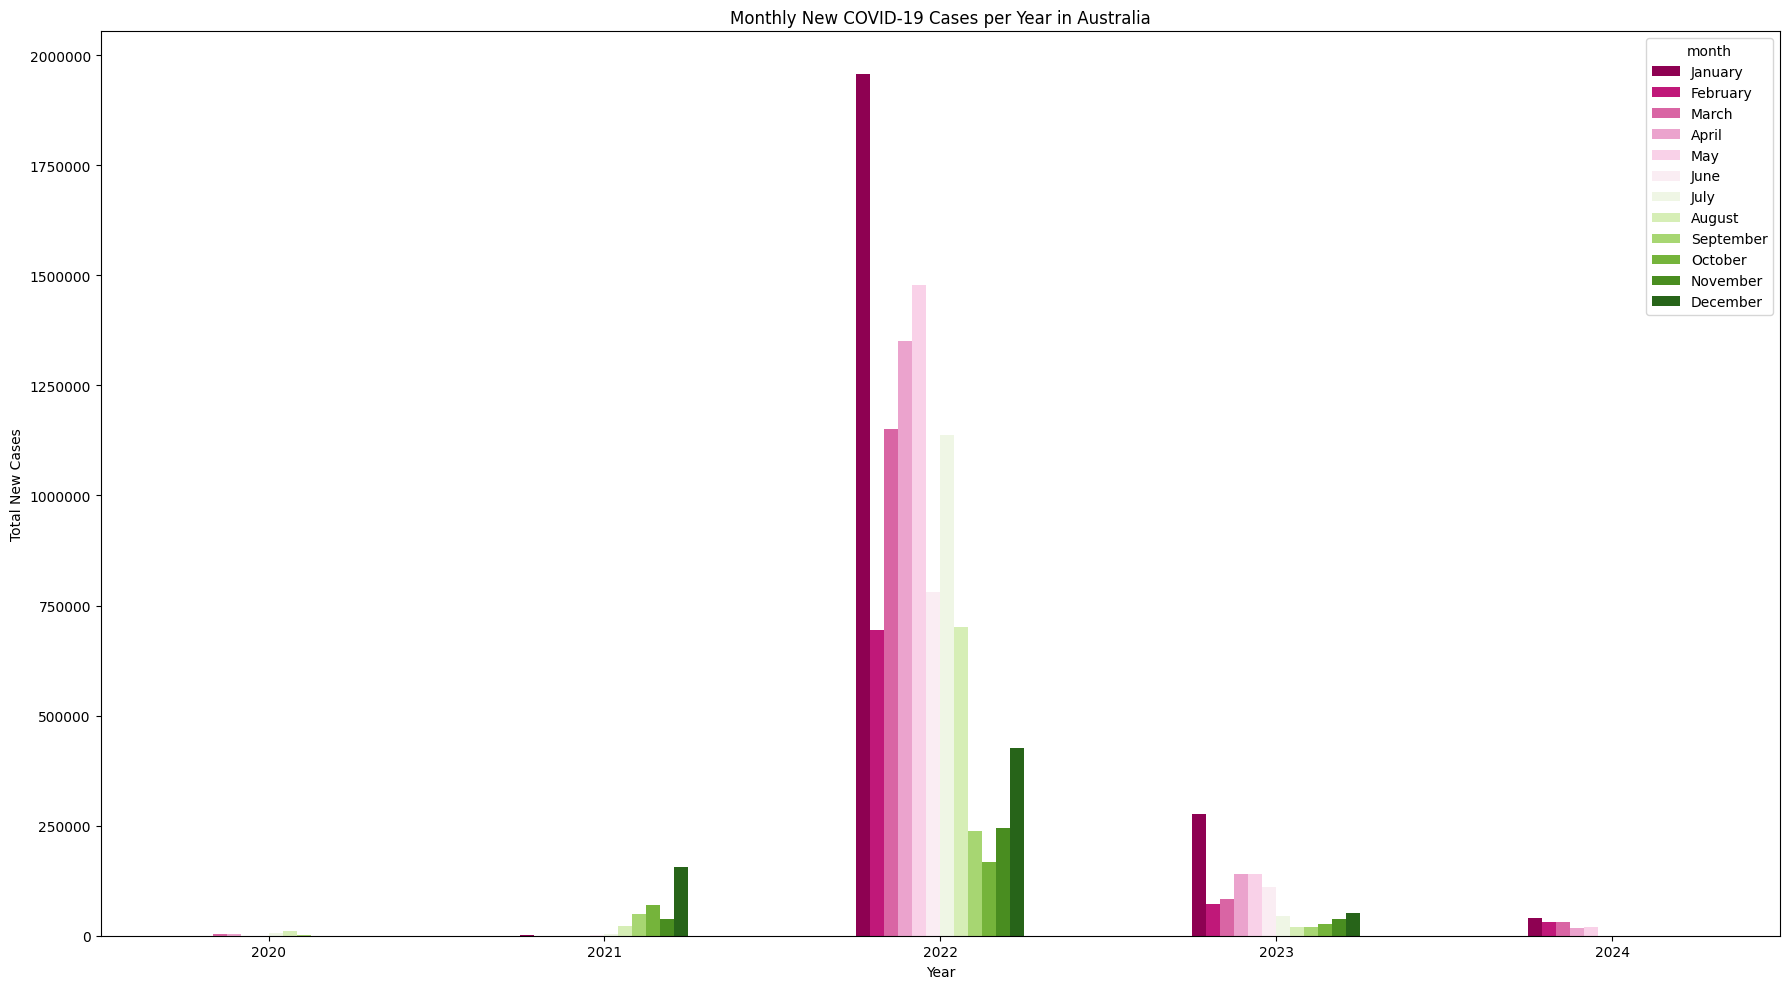

In [19]:
monthly_cases_each_year.plot(kind='bar', figsize=(18, 10), colormap='PiYG')
plt.title("Monthly New COVID-19 Cases per Year in Australia")
plt.xlabel('Year')
plt.ylabel('Total New Cases')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

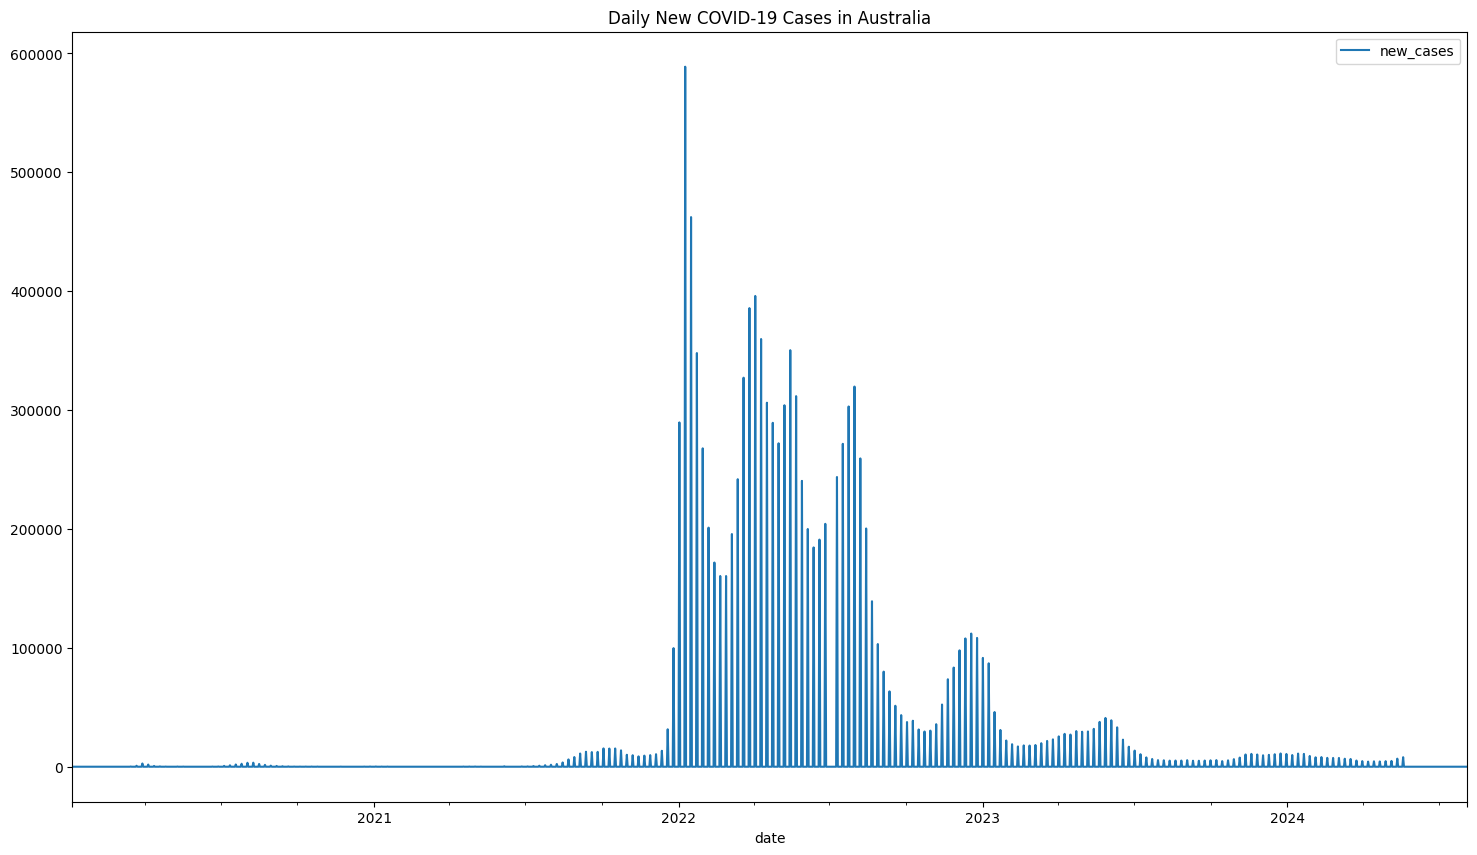

In [20]:
australia.plot(x='date', y='new_cases', title='Daily New COVID-19 Cases in Australia', figsize=(18, 10))
plt.show()